#  **Numerical weather prediction using neural networks**

## **Imports**

In [ ]:
import os
import time
import random
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


## Random Seed genearation for reproducability

In [ ]:
SEED = 42




random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

torch.use_deterministic_algorithms(True)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

## Loading the data set

In [ ]:
data_file=pd.read_excel("/content/drive/MyDrive/E.M.Y_project/Λάρισα_data(16648).xlsx")
data_file.drop(columns=['Unnamed: 0'], inplace=True)
data_file.drop(columns=['PRODUCTID'], inplace=True)




for col in data_file.columns:
    data_file[col] = data_file[col].astype(str).str.replace(',', '.').astype(float)



id_col = ["WMONO"]

time_cols = [
    "OBSERVATIONYEAR",
    "OBSERVATIONMONTH",
    "OBSERVATIONDAY",
    "OBSERVATIONHOUR"
]

target_cols = [
    "DRYTEMP", "MAXTEMP", "MINTEMP", "RELHUMIDITY",
    "PRECIPHEIGHT", "WETTEMP", "VISIBILITY",
    "WINDDIRECTION", "WINDFORCEKNOT", "DEWLINGPOINT",
    "HYDRTENDENCY"
]

interpolation_cols = [
    "DRYTEMP", "RELHUMIDITY",
    "WETTEMP", "VISIBILITY",
    "WINDFORCEKNOT", "DEWLINGPOINT",
]



train=data_file[data_file['OBSERVATIONYEAR']<=2016]
val=data_file[(data_file['OBSERVATIONYEAR']<=2019) & (data_file['OBSERVATIONYEAR']>=2017)]
test=data_file[(data_file['OBSERVATIONYEAR']==2020)]



feature_cols = list(train.columns)

## Preprocessing Utilities

In [ ]:
def create_sequences(X, y, seq_len, pred_len, test=False):
    X_seq, y_seq, indices = [], [], []

    for i in range(len(X) - seq_len - pred_len + 1):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len:i + seq_len + pred_len])

        # first timestep being predicted
        indices.append(i + seq_len)
    if test:
        return np.array(X_seq), np.array(y_seq), np.array(indices)

    return np.array(X_seq), np.array(y_seq)





def fit_transform_per_label(train_df, val_df, test_df, cols):
  scalers = {}

  train_scaled = train_df.copy()
  val_scaled   = val_df.copy()
  test_scaled  = test_df.copy()

  for col in cols:
    scaler = StandardScaler()

    train_scaled[[col]] = scaler.fit_transform(train_df[[col]])
    val_scaled[[col]]   = scaler.transform(val_df[[col]])
    test_scaled[[col]]  = scaler.transform(test_df[[col]])

    scalers[col] = scaler

  return train_scaled, val_scaled, test_scaled, scalers


def inverse_transform_per_label(arr, scalers, target_cols):
  original_shape = arr.shape
  arr_2d = arr.reshape(-1, arr.shape[-1])
  inversed = np.zeros_like(arr_2d)

  for i, col in enumerate(target_cols):
      inversed[:, i] = scalers[col].inverse_transform(
          arr_2d[:, [i]]
      ).ravel()

  return inversed.reshape(original_shape)

In [ ]:
def preprocess_data(train, val, test, time_cols, target_cols,
                     seq_len, pred_len, batch_size, generator):

    interpolation_cols = [
        "DRYTEMP", "RELHUMIDITY",
        "WETTEMP", "VISIBILITY",
        "WINDFORCEKNOT", "DEWLINGPOINT",
    ]

    train = train.copy()
    val   = val.copy()
    test  = test.copy()

    train[interpolation_cols] = train[interpolation_cols].interpolate(method="linear").ffill().bfill()
    val[interpolation_cols]   = val[interpolation_cols].interpolate(method="linear").ffill().bfill()
    test[interpolation_cols]  = test[interpolation_cols].interpolate(method="linear").ffill().bfill()






    temp = pd.DataFrame({
    'timestamp': pd.to_datetime(train[['OBSERVATIONYEAR', 'OBSERVATIONMONTH', 'OBSERVATIONDAY', 'OBSERVATIONHOUR']].rename(
        columns={
            'OBSERVATIONYEAR': 'year',
            'OBSERVATIONMONTH': 'month',
            'OBSERVATIONDAY': 'day',
            'OBSERVATIONHOUR': 'hour'
            }
        ) )
    })

    plt.figure(figsize=(10, 8))
    plt.plot(temp["timestamp"], train["WETTEMP"])
    plt.title("WETTEMP Value Progression Over Time after linear interpolation")
    plt.xlabel("Time")
    plt.ylabel("WETTEMP")
    plt.grid(True)
    plt.show()

    train = train.fillna(0)
    val   = val.fillna(0)
    test  = test.fillna(0)

    input_cols=time_cols+target_cols

    X_train = train[input_cols].copy()
    X_val   = val[input_cols].copy()
    X_test  = test[input_cols].copy()

    y_train = train[target_cols].copy()
    y_val   = val[target_cols].copy()
    y_test  = test[target_cols].copy()

    # Per-label scaling
    X_train_scaled, X_val_scaled, X_test_scaled, x_scalers = fit_transform_per_label(
        X_train, X_val, X_test, target_cols
    )

    y_train_scaled, y_val_scaled, y_test_scaled, y_scalers = fit_transform_per_label(
        y_train, y_val, y_test, target_cols
    )

    X_train_scaled = X_train_scaled.values.astype(float)
    X_val_scaled   = X_val_scaled.values.astype(float)
    X_test_scaled  = X_test_scaled.values.astype(float)

    y_train_scaled = y_train_scaled.values.astype(float)
    y_val_scaled   = y_val_scaled.values.astype(float)
    y_test_scaled  = y_test_scaled.values.astype(float)





    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_len, pred_len)

    X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, seq_len, pred_len)

    X_test_seq, y_test_seq, test_indices = create_sequences(X_test_scaled, y_test_scaled, seq_len, pred_len, test=True)

    train_dataset = TensorDataset(
        torch.tensor(X_train_seq, dtype=torch.float32),
        torch.tensor(y_train_seq, dtype=torch.float32),

    )

    val_dataset = TensorDataset(
        torch.tensor(X_val_seq, dtype=torch.float32),
        torch.tensor(y_val_seq, dtype=torch.float32),

    )

    test_dataset = TensorDataset(
        torch.tensor(X_test_seq, dtype=torch.float32),
        torch.tensor(y_test_seq, dtype=torch.float32),

    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, test_indices, x_scalers, y_scalers

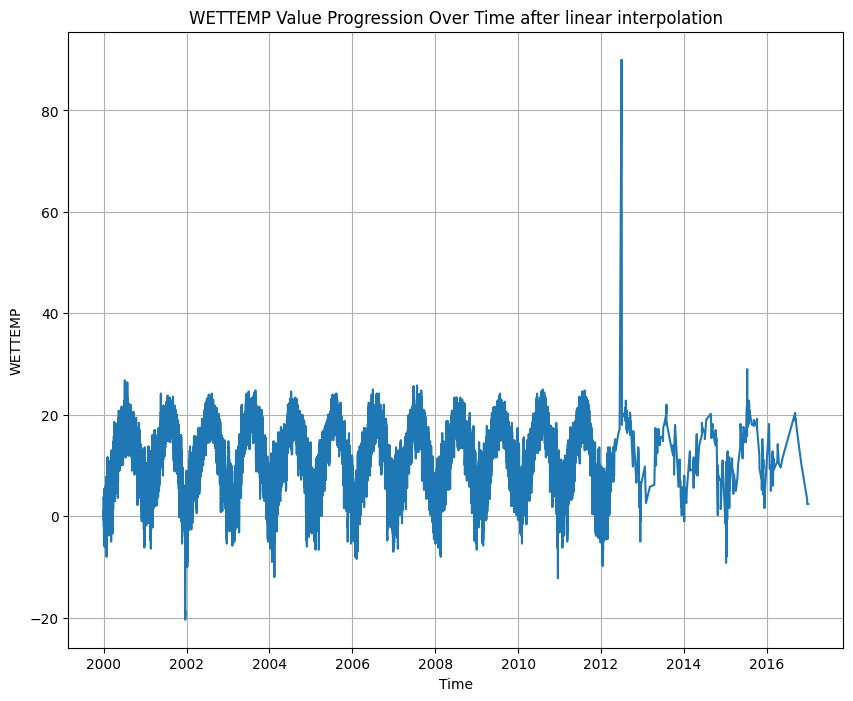

In [ ]:

original_time_test = test[[
    "OBSERVATIONYEAR",
    "OBSERVATIONMONTH",
    "OBSERVATIONDAY",
    "OBSERVATIONHOUR"
]].reset_index(drop=True)

# optional if you have IDs
if "WMONO" in test.columns:
    original_id_test = test["WMONO"].reset_index(drop=True)
else:
    original_id_test = None


seq_len =  224
pred_len = 168
batch_size = 32



train_loader, val_loader, test_loader, test_indices, x_scalers, y_scalers = preprocess_data(train,
                                                                                val,
                                                                                test,
                                                                                time_cols,
                                                                                target_cols,
                                                                                seq_len,
                                                                                pred_len,
                                                                                batch_size,
                                                                                generator=g)



## Initial neural netwrok implementaion and related functions (Specific chapters to be writen later)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model_regression(model, dataloader, criterion, device='cpu', flag=None, y_scaler=None):
    """
    Evaluates a regression model and optionally returns inverse-scaled predictions for the test set.

    Parameters:
    - model: PyTorch model
    - dataloader: DataLoader for the dataset
    - criterion: loss function
    - device: 'cpu' or 'cuda'
    - flag: if 'test', returns predictions as well
    - y_scaler: fitted scaler used on y (for inverse-transforming predictions)

    Returns:
    - avg_loss, mse, mae, r2
    - if flag='test': also returns inverse-scaled predictions
    """
    model.eval()
    model.to(device)

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Stack and flatten batch & sequence dimensions
    all_preds = np.vstack(all_preds)  # shape: (num_batches*batch_size, seq_len, output_dim)
    all_labels = np.vstack(all_labels)

    # Flatten to 2D for metrics: (batch*seq_len, output_dim)
    all_preds = all_preds.reshape(-1, all_preds.shape[-1])
    all_labels = all_labels.reshape(-1, all_labels.shape[-1])

    avg_loss = total_loss / len(dataloader)
    mse = mean_squared_error(all_labels, all_preds)
    mae = mean_absolute_error(all_labels, all_preds)





    return avg_loss, mse, mae

In [ ]:
def evaluate_model_regression_test(model,
                                   dataloader,
                                   criterion,
                                   test_indices,
                                   y_scalers,
                                   original_time_test,
                                   target_cols,
                                   pred_len,
                                   save_path="test_predictions.csv",
                                   device='cpu',
                                   flag=None,
                                   original_id_test=None):

    model.eval()
    model.to(device)

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            all_preds.append(outputs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    preds = np.concatenate(all_preds, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    # inverse transform, then restore 3D shape
    preds_reshaped = preds.reshape(-1, preds.shape[-1])
    labels_reshaped = labels.reshape(-1, labels.shape[-1])

    preds_inverse = inverse_transform_per_label(
        preds_reshaped, y_scalers, target_cols
    ).reshape(preds.shape)

    labels_inverse = inverse_transform_per_label(
        labels_reshaped, y_scalers, target_cols
    ).reshape(labels.shape)

    avg_loss = total_loss / len(dataloader)

    # full-horizon metrics
    mse = mean_squared_error(
        labels_inverse.reshape(-1, labels_inverse.shape[-1]),
        preds_inverse.reshape(-1, preds_inverse.shape[-1])
    )

    mae = mean_absolute_error(
        labels_inverse.reshape(-1, labels_inverse.shape[-1]),
        preds_inverse.reshape(-1, preds_inverse.shape[-1])
    )

    print(f"Test Loss: {avg_loss:.7f}")
    print(f"Test MSE full horizon: {mse:.7f}")
    print(f"Test MAE full horizon: {mae:.7f}")

    # save only last predicted timestep for plotting
    final_preds = preds_inverse[:, -1, :]

    aligned_time = original_time_test.iloc[
        test_indices + pred_len - 1
    ].reset_index(drop=True)

    pred_df = pd.DataFrame(final_preds, columns=target_cols)

    final_df = pd.concat([aligned_time, pred_df], axis=1)

    if original_id_test is not None:
        aligned_id = original_id_test.iloc[
            test_indices + pred_len - 1
        ].reset_index(drop=True)

        final_df.insert(0, "WMONO", aligned_id)

    final_df.to_csv(save_path, index=False)

    print(f"Predictions saved to: {save_path}")

    return final_df

In [ ]:
class Transformer(nn.Module):
    def __init__(self, num_features, model_dim, num_heads, num_layers,
                 output_dim, max_seq_len, pred_len):
        super().__init__()

        self.pred_len = pred_len
        self.output_dim = output_dim

        self.feature_proj = nn.Linear(num_features, model_dim)

        self.pos_embedding = nn.Parameter(
            torch.randn(1, max_seq_len, model_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=256,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # predict all future steps at once
        self.fc_out = nn.Linear(model_dim, pred_len * output_dim)

    def forward(self, x):
        x = self.feature_proj(x)
        x = x + self.pos_embedding[:, :x.size(1), :]

        x = self.transformer_encoder(x)

        # use last encoded timestep
        x = x[:, -1, :]

        out = self.fc_out(x)

        # shape: (batch_size, pred_len, output_dim)
        out = out.view(-1, self.pred_len, self.output_dim)

        return out

In [ ]:
def train_model_regression(model, train_loader, val_loader, optimizer, criterion, num_epochs, device='cpu'):
    model.to(device)
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # Validation
        val_loss, mse, mae = evaluate_model_regression(model, val_loader, criterion, device=device)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | MSE: {mse:.4f} | MAE: {mae:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nBest model restored with Val Loss: {best_val_loss:.4f}")

    return model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


input_cols=time_cols+target_cols
num_features = len(input_cols)
output_dim = len(target_cols)
model_dim = 32
num_heads = 8
num_layers = 2








model = Transformer(num_features, model_dim, num_heads, num_layers, output_dim, seq_len, pred_len)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
num_epochs = 10

trained_model = train_model_regression(model, train_loader, val_loader, optimizer, criterion, num_epochs, device=device)


Epoch 1/10 | Train Loss: 1.0020 | Val Loss: 0.8987 | MSE: 0.8974 | MAE: 0.7119
Epoch 2/10 | Train Loss: 0.7517 | Val Loss: 0.6507 | MSE: 0.6490 | MAE: 0.5571
Epoch 3/10 | Train Loss: 0.6547 | Val Loss: 0.5908 | MSE: 0.5891 | MAE: 0.5156
Epoch 4/10 | Train Loss: 0.5956 | Val Loss: 0.5837 | MSE: 0.5821 | MAE: 0.4996
Epoch 5/10 | Train Loss: 0.5579 | Val Loss: 0.5673 | MSE: 0.5657 | MAE: 0.4797
Epoch 6/10 | Train Loss: 0.5434 | Val Loss: 0.5644 | MSE: 0.5628 | MAE: 0.4752
Epoch 7/10 | Train Loss: 0.5342 | Val Loss: 0.5634 | MSE: 0.5617 | MAE: 0.4693
Epoch 8/10 | Train Loss: 0.5264 | Val Loss: 0.5624 | MSE: 0.5607 | MAE: 0.4684
Epoch 9/10 | Train Loss: 0.5221 | Val Loss: 0.5802 | MSE: 0.5784 | MAE: 0.4844
Epoch 10/10 | Train Loss: 0.5186 | Val Loss: 0.5516 | MSE: 0.5500 | MAE: 0.4599

Best model restored with Val Loss: 0.5516


In [ ]:
def plot_test_vs_predictions(
    test,
    predictions,
    target_cols,
    save_dir=None,
    pred_len=24,
    show=True
):
    # Keep only the part of test that matches prediction length
    test_plot = test.iloc[-len(predictions):].reset_index(drop=True)
    predictions_plot = predictions.reset_index(drop=True)

    temp = pd.DataFrame({
        "timestamp": pd.to_datetime(
            test_plot[[
                "OBSERVATIONYEAR",
                "OBSERVATIONMONTH",
                "OBSERVATIONDAY",
                "OBSERVATIONHOUR"
            ]].rename(columns={
                "OBSERVATIONYEAR": "year",
                "OBSERVATIONMONTH": "month",
                "OBSERVATIONDAY": "day",
                "OBSERVATIONHOUR": "hour"
            })
        )
    })

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for col in target_cols:
        plt.figure(figsize=(10, 8))

        plt.plot(
            temp["timestamp"],
            test_plot[col].values,
            label=f"True {col}"
        )

        plt.plot(
            temp["timestamp"],
            predictions_plot[col].values,
            label=f"Predicted {col}",
            alpha=0.5
        )

        plt.title(f"{col}: Test vs Prediction")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.grid(True)
        plt.legend()

        if save_dir is not None:
            plt.savefig(
                os.path.join(save_dir, f"{col}_test_vs_prediction{pred_len}.png"),
                dpi=300,
                bbox_inches="tight"
            )

        if show:
            plt.show()
        else:
            plt.close()

Test Loss: 0.5355589
Test MSE full horizon: 777.3759155
Test MAE full horizon: 9.6480293
Predictions saved to: /content/drive/MyDrive/E.M.Y_project/test_predictions_trans_56-24.csv


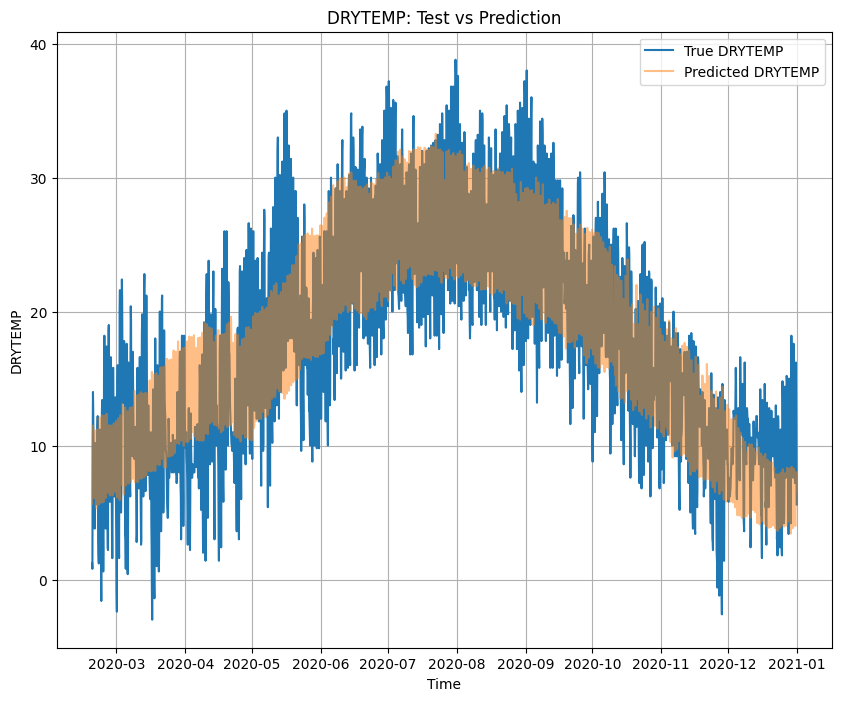

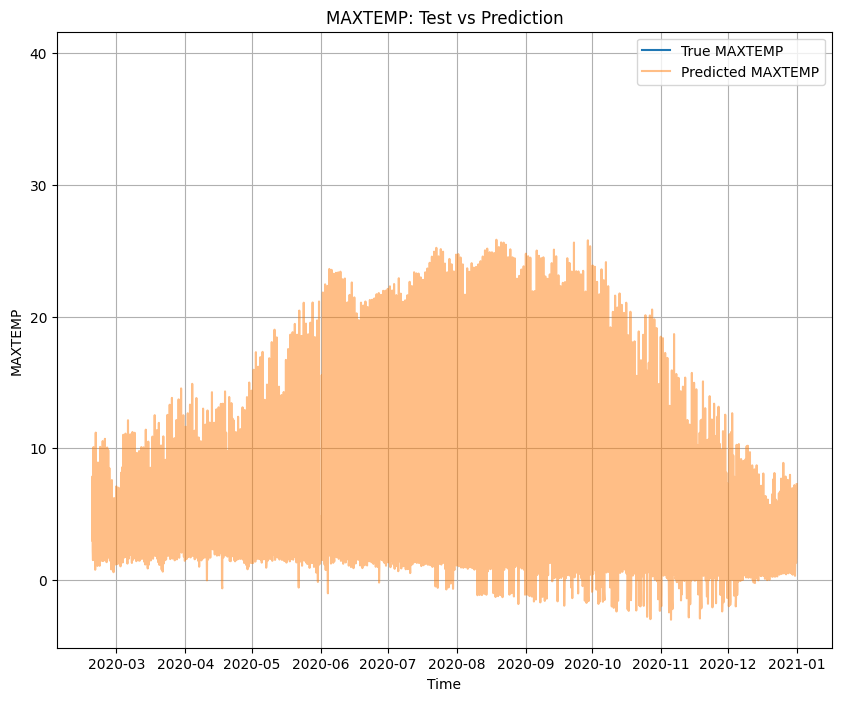

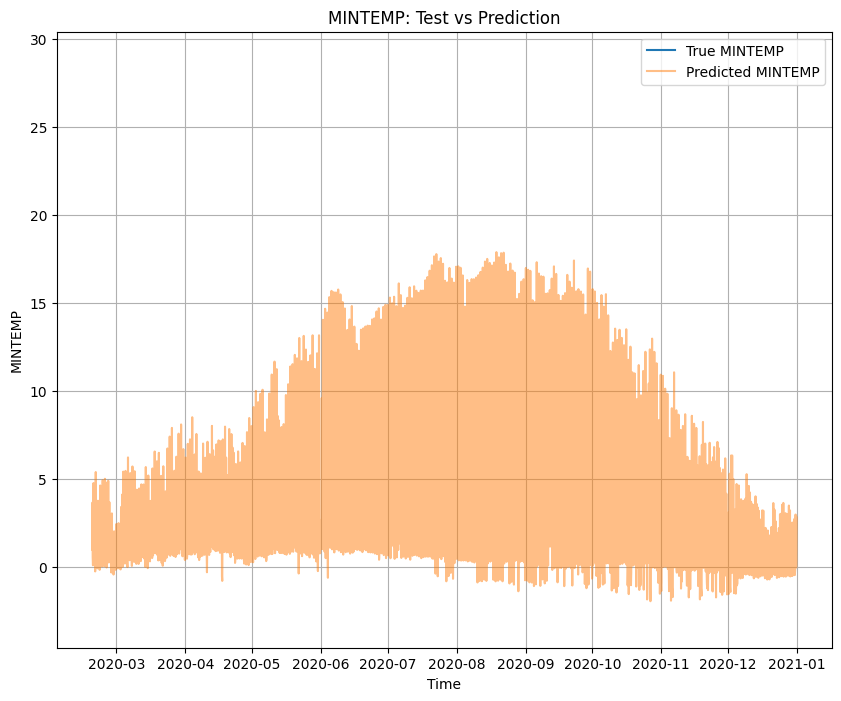

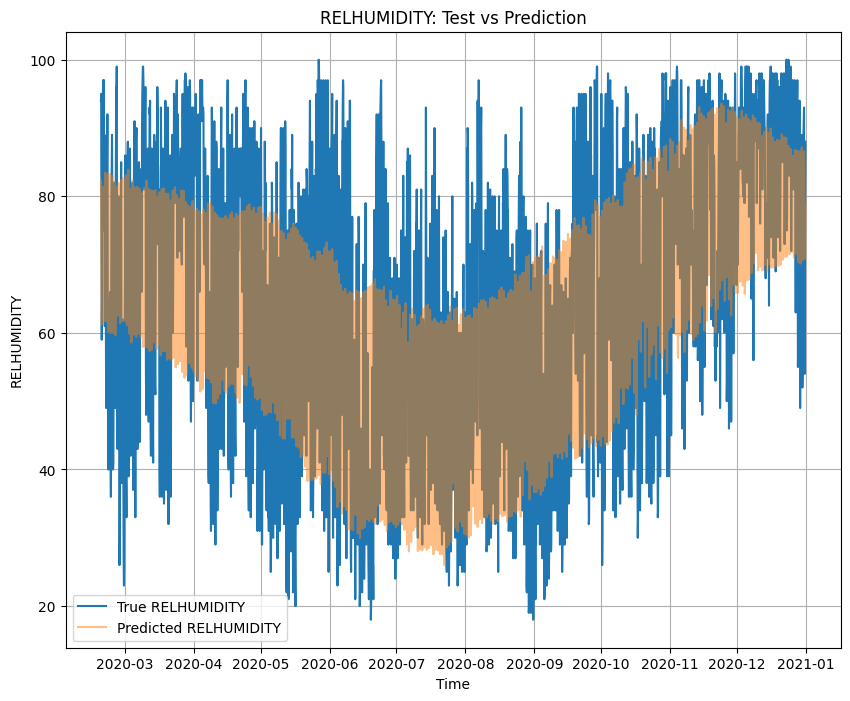

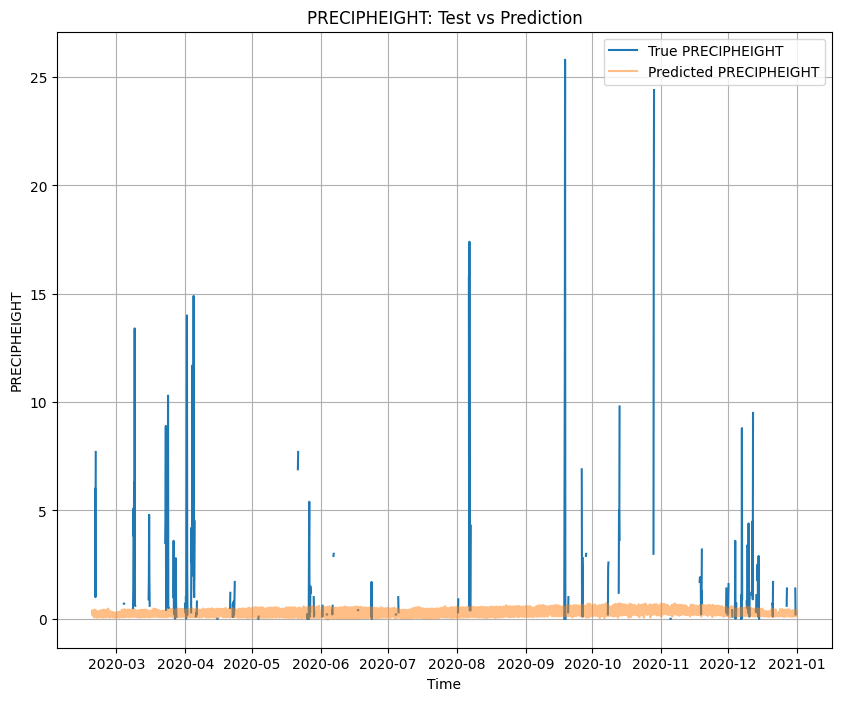

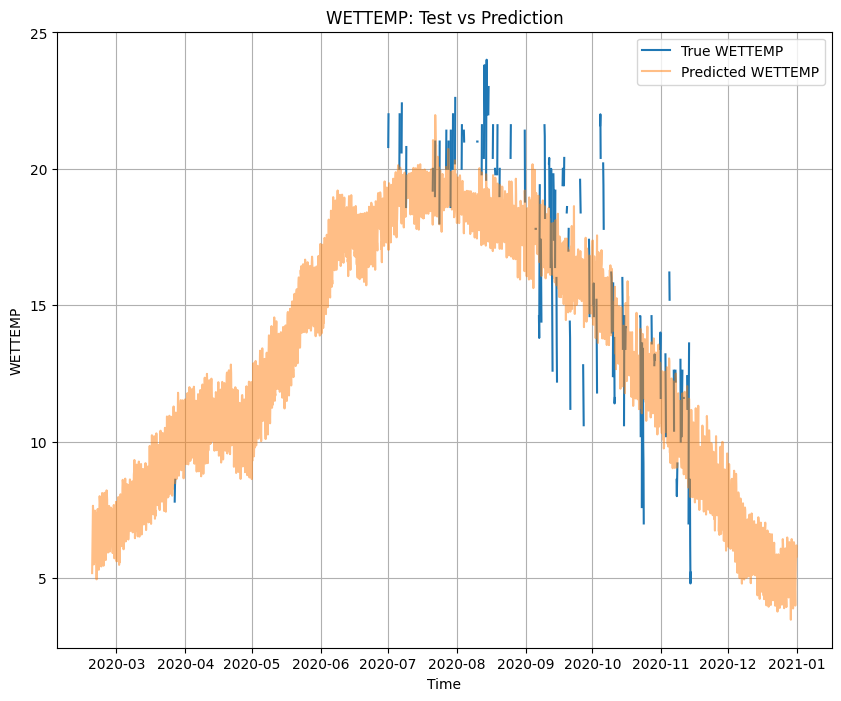

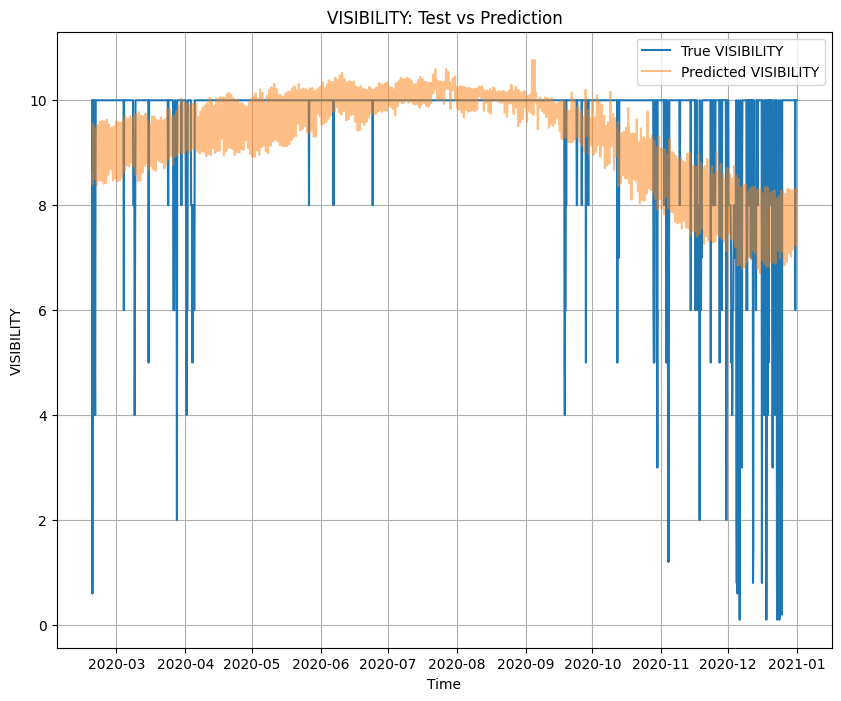

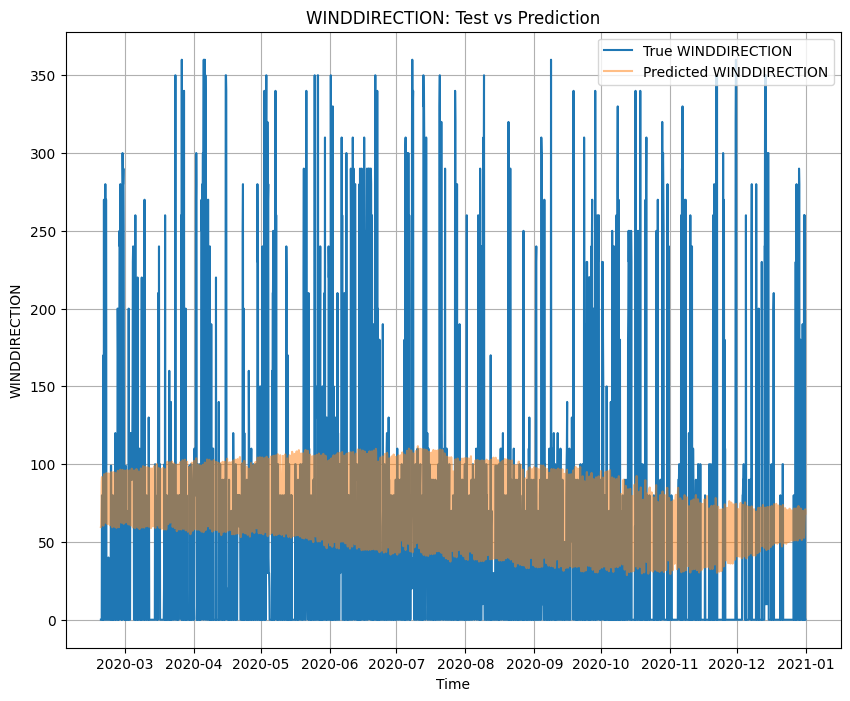

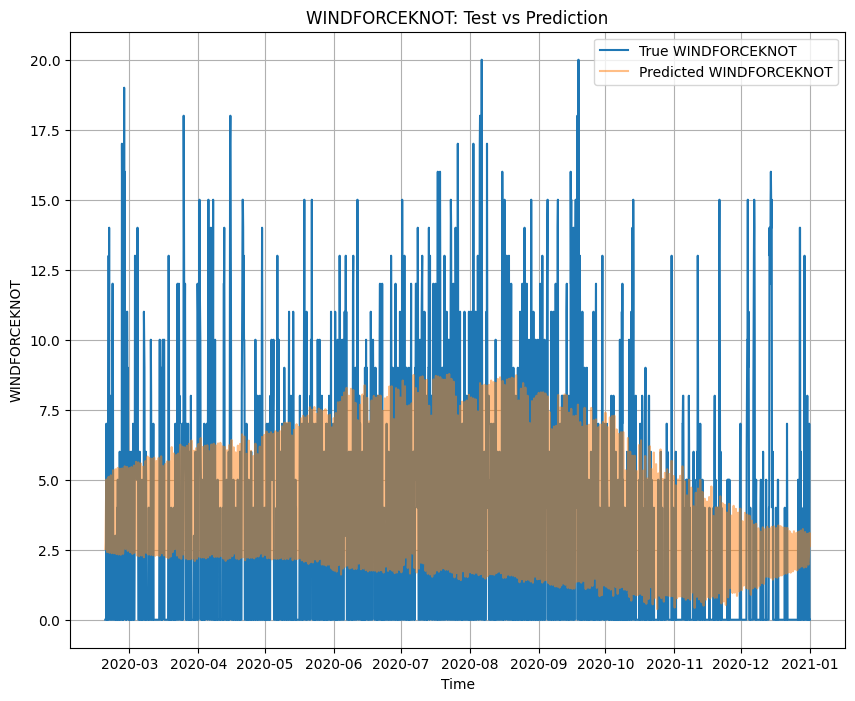

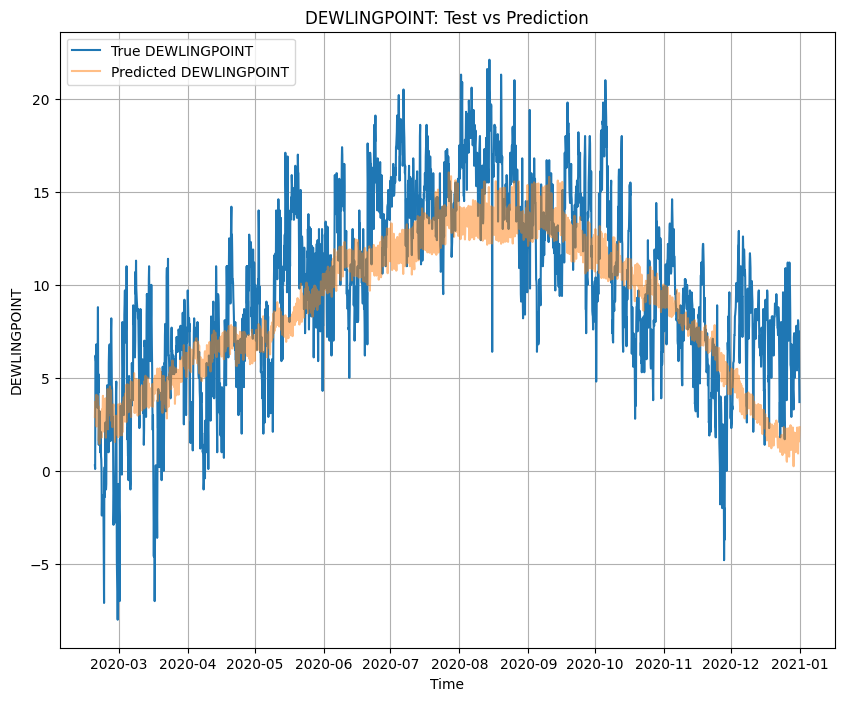

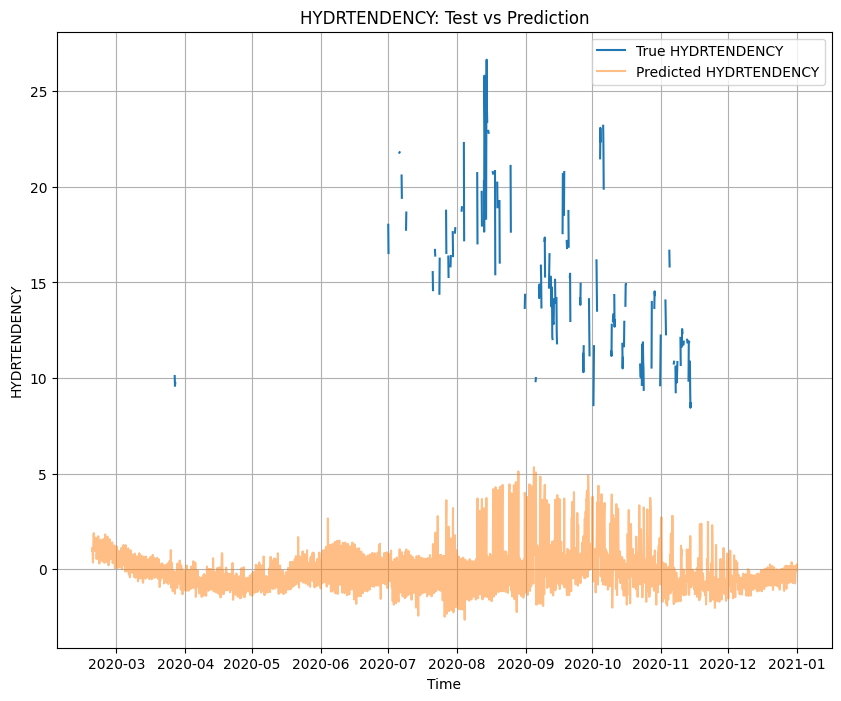

In [ ]:
save_path="/content/drive/MyDrive/E.M.Y_project/test_predictions_trans_56-24.csv"

predict_df = evaluate_model_regression_test(
    model=trained_model,
    dataloader=test_loader,
    criterion=criterion,
    y_scalers=y_scalers,
    original_time_test=original_time_test,
    target_cols=target_cols,
    device=device,
    pred_len=pred_len,
    test_indices=test_indices,
    save_path=save_path,
    original_id_test=original_id_test
)



plot_test_vs_predictions(
    test=test,
    predictions=predict_df,
    target_cols=target_cols,
    pred_len=pred_len,
    save_dir="/content/drive/MyDrive/E.M.Y_project/test_vs_predicted/transformer"
)

